In [ ]:
!pip install -q kagglehub

import kagglehub

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
print('Dataset path:', path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Dataset path: /kaggle/input/skin-cancer-mnist-ham10000


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
part1 = os.path.join(path, 'ham10000_images_part_1')
part2 = os.path.join(path, 'ham10000_images_part_2')
merged_dir = '/content/ham10000_all_images'
os.makedirs(merged_dir, exist_ok=True)

for folder in [part1, part2]:
    if os.path.isdir(folder):
        for img_file in os.listdir(folder):
            src = os.path.join(folder, img_file)
            dst = os.path.join(merged_dir, img_file)
            if not os.path.exists(dst):
                shutil.copy(src, dst)

print('Merged images count:', len(os.listdir(merged_dir)))

Merged images count: 10015


In [ ]:
df = pd.read_csv(os.path.join(path, 'HAM10000_metadata.csv'))
df['image_path'] = df['image_id'].apply(lambda x: os.path.join(merged_dir, x + '.jpg'))
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['dx'], random_state=42)
print('Train samples:', len(train_df))
print('Validation samples:', len(val_df))

Train samples: 8012
Validation samples: 2003


In [ ]:
img_size = (224, 224)  # REQUIRED FOR RESNET50!
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='dx',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='dx',
    target_size=img_size,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

num_classes = len(train_gen.class_indices)

Found 8012 validated image filenames belonging to 7 classes.
Found 2003 validated image filenames belonging to 7 classes.


In [ ]:

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load ResNet50 base
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pre-trained layers
base_model.trainable = False

# Build new classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)
output_layer = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,640,391 (94.00 MB)

 Trainable params: 1,052,679 (4.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
EPOCHS = 15

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 179s 652ms/step - accuracy: 0.6434 - loss: 1.3173 - val_accuracy: 0.6695 - val_loss: 1.1349
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 150s 597ms/step - accuracy: 0.6748 - loss: 1.1488 - val_accuracy: 0.6695 - val_loss: 1.1262
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 586ms/step - accuracy: 0.6685 - loss: 1.1541 - val_accuracy: 0.6695 - val_loss: 1.1256
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 588ms/step - accuracy: 0.6664 - loss: 1.1590 - val_accuracy: 0.6695 - val_loss: 1.1292
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 147s 587ms/step - accuracy: 0.6635 - loss: 1.1548 - val_accuracy: 0.6695 - val_loss: 1.1131
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 148s 589ms/step - accuracy: 0.6667 - loss: 1.1459 - val_accuracy: 0.6695 - val_loss: 1.1118
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 581ms/step - accuracy: 0.6745 - loss: 1.1322 - val_accuracy: 0.6695 - val_loss: 1.1110
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 146s 581ms/step - accuracy: 0.6605 -

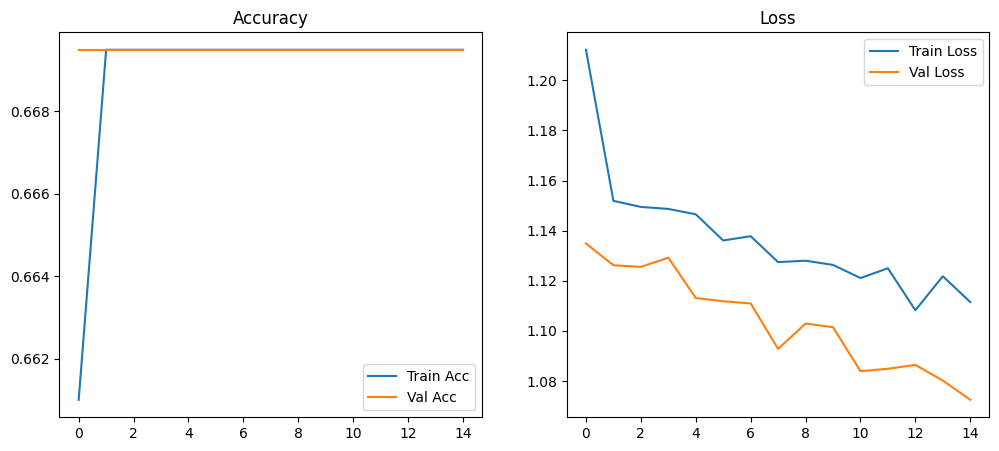

In [9]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted: nv


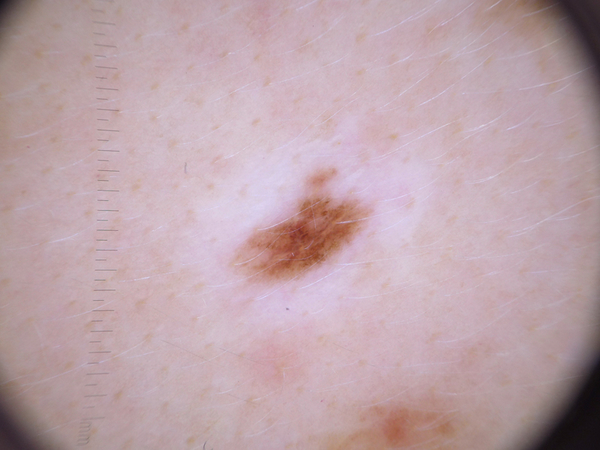

In [10]:
class_indices = train_gen.class_indices
inv_class_indices = {v:k for k,v in class_indices.items()}

from IPython.display import display

def predict_skin_image(img_path):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    preds = model.predict(img_array)
    idx = np.argmax(preds[0])
    label = inv_class_indices[idx]
    print('Predicted:', label)
    display(image.load_img(img_path))

# Example: predict on first validation image
sample = val_df.iloc[0]['image_path']
predict_skin_image(sample)

In [11]:
model.save('skin_disease_cnn_model.h5')
print('Model saved to skin_disease_cnn_model.h5')

Model saved to skin_disease_cnn_model.h5
